In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup works like a charm!")

Setup works like a charm!


In [2]:
import pandas as pd
#This dataset comes the EIA whose files are often messy, so check the first 10 rows. 
with open("data/raw/henry_hub_natural_gas_prices.csv", "r", encoding="utf-8") as f:
    for i in range(10):
        print(repr(f.readline()))

#Load raw Henry Hub gas daily price dataset and skip the first 5 rows. 
df = pd.read_csv("data/raw/henry_hub_natural_gas_prices.csv", 
                skiprows=4
                )
#preview data
print(df.head())



'Henry Hub Natural Gas Spot Price\n'
'https://www.eia.gov/dnav/ng/hist/rngwhhdD.htm\n'
'10:29:48 GMT-0500 (Central Daylight Time)\n'
'Data Source: Thomson Reuters\n'
'Day,Henry Hub Natural Gas Spot Price Dollars per Million Btu\n'
'03/23/2026,2.94\n'
'03/20/2026,3.04\n'
'03/19/2026,3.21\n'
'03/18/2026,3.12\n'
'03/17/2026,3.14\n'
          Day  Henry Hub Natural Gas Spot Price Dollars per Million Btu
0  03/23/2026                                               2.94       
1  03/20/2026                                               3.04       
2  03/19/2026                                               3.21       
3  03/18/2026                                               3.12       
4  03/17/2026                                               3.14       


In [3]:
#Let's do some data cleaning
#Keep only the date and gas price columns and rename them "day" and "price" respectively. 
df = df.rename(columns={
    df.columns[0]: "day",
    df.columns[1]: "price"
}) 
#Convert date and price columns into correct data types and correct null values if necessary
df["day"] = pd.to_datetime(df["day"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

#Drop any missing values
df = df.dropna()

#Sort by oldest to newest daily price
df = df.sort_values("day")

#For this project, I am only looking at gas prices from the last 12 months
max_date = df["day"].max()
print(max_date)

df_12m = df[df["day"] >= "2025-03-23"]
print(df_12m.head())
print(df_12m.tail())
df_12m.to_csv("data/processed/henry_hub_gas_prices_12Months.csv", index=False)

2026-03-23 00:00:00
           day  price
246 2025-03-24   4.03
245 2025-03-25   3.94
244 2025-03-26   3.85
243 2025-03-27   3.88
242 2025-03-28   3.89
         day  price
4 2026-03-17   3.14
3 2026-03-18   3.12
2 2026-03-19   3.21
1 2026-03-20   3.04
0 2026-03-23   2.94


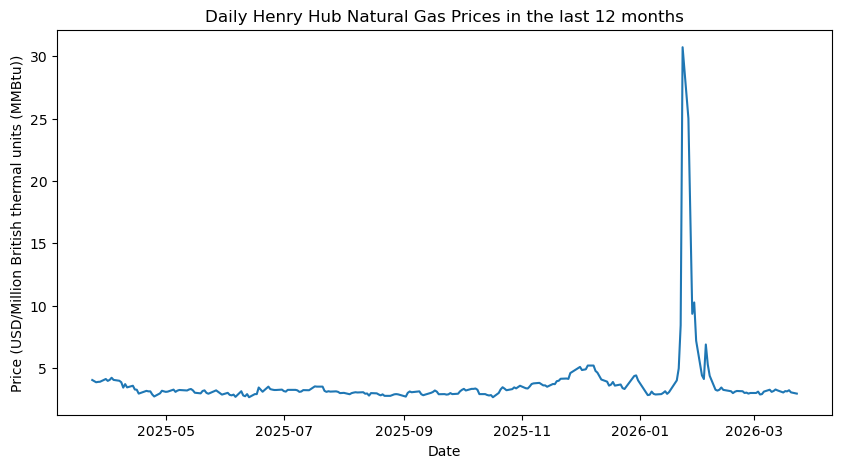

In [4]:
#Let's do some visualization. We'll use real energy market data to simulate exposure movements
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_12m["day"], df_12m["price"])
plt.title("Daily Henry Hub Natural Gas Prices in the last 12 months")
plt.xlabel("Date")
plt.ylabel("Price (USD/Million British thermal units (MMBtu))")
plt.savefig("outputs/henry_hub_price_chart.png")
plt.show()

In [5]:
#Now let's simulate a trading book of counterparties for a power company (i.e., an entity on the other side of a transaction like a whole
#sale power buyer/seller like a grid operter like ERCOT, or a commercial customer ike a Meta data center, or a bank like Goldman Sachs
#I do not have data from real counterparties, like a real energy company would, so these numbers are randomly generated.
counterparties = pd.DataFrame({
    "counterparty": ["A", "B", "C", "D", "E"],        #These are energy trading partners the power company would have such as ERCOT, Goldman, or Meta
    "position_size": [10000, 8000, 12000, 6000, 9000], #Position size is the amount of a commodity (in this case, units of gas) being traded. Bigger position => larger exposure (risk from gas prices changing)   
    "direction": ["long", "short", "long", "short", "long"], #Tells you how exposure risk is affected by market prices.  long = power company benefits when prices raise, Short = they benefit when prices fall
    "collateral_posted": [150000, 100000, 120000, 80000, 110000], #How much money counterparty posted. Bigger collateral = Less exposure(risk) for power company
    "threshold": [100000, 80000, 90000, 70000, 85000], #Credit limit before power company demands collateral from counterparty based on their creditworthiness
    "minimum_transfer": [25000, 25000, 25000, 20000, 25000], #smallest margin call allowed
    "credit_rating": ["A", "BBB", "BB", "A", "BBB"], # creditworthiness rating of counterparties. A = strong, BBB = ok, BB = risky
    "dispute_flag": ["No", "No", "Yes", "No", "No"]  # If power company disagrees on exposure calculations with counterparty
})
print(counterparties.head())


  counterparty  position_size direction  collateral_posted  threshold  \
0            A          10000      long             150000     100000   
1            B           8000     short             100000      80000   
2            C          12000      long             120000      90000   
3            D           6000     short              80000      70000   
4            E           9000      long             110000      85000   

   minimum_transfer credit_rating dispute_flag  
0             25000             A           No  
1             25000           BBB           No  
2             25000            BB          Yes  
3             20000             A           No  
4             25000           BBB           No  


In [6]:
#Now let's merge today's (03/23/2026) gas price with the counterparty dataset from the gas price dataset to simulate power company's current exposure
lastest_price = df_12m.iloc[-1]["price"]  #go to the price column in the df_12m dataframe and selected the bottom-most value
print(lastest_price)
counterparties["price"] = lastest_price
counterparties.head()

,counterparty,position_size,direction,collateral_posted,threshold,minimum_transfer,credit_rating,dispute_flag,price
0,A,10000,long,150000,100000,25000,A,No,2.94
1,B,8000,short,100000,80000,25000,BBB,No,2.94
2,C,12000,long,120000,90000,25000,BB,Yes,2.94
3,D,6000,short,80000,70000,20000,A,No,2.94
4,E,9000,long,110000,85000,25000,BBB,No,2.94


In [7]:
#Let's calculate the market value of these positions (position_size x today's gas price).
def calculate_market_value(row):
    value = row["position_size"] * row["price"]

    if row["direction"] == "short":
        value = -value
    return abs(value)
counterparties["market_value"] = counterparties.apply(calculate_market_value, axis=1)
counterparties.head()

,counterparty,position_size,direction,collateral_posted,threshold,minimum_transfer,credit_rating,dispute_flag,price,market_value
0,A,10000,long,150000,100000,25000,A,No,2.94,29400.0
1,B,8000,short,100000,80000,25000,BBB,No,2.94,23520.0
2,C,12000,long,120000,90000,25000,BB,Yes,2.94,35280.0
3,D,6000,short,80000,70000,20000,A,No,2.94,17640.0
4,E,9000,long,110000,85000,25000,BBB,No,2.94,26460.0


In [8]:
#Let's calculate the adjusted threshold based on each counterparty's threshold and today's (03/23/2026) gas price
#Since a credit rating of "A" is the least risky, anything lower should lower the counterparty's credit limit
def adjust_threshold(row):
    if row["credit_rating"] == "BBB":
        return row["threshold"] * 0.8
    elif row["credit_rating"] == "BB":
        return row["threshold"] * 0.6
    return row["threshold"]
counterparties["adjusted_threshold"] = counterparties.apply(adjust_threshold, axis=1)
#Calculate net exposure (how much gas is at stake minus the collateral the CP is willing to put up)
counterparties["net_exposure"] = counterparties["market_value"] - counterparties["collateral_posted"]
counterparties.head()
#Let's determine if today's natural gas prices require a margin call from any of the CPs.
def margin_call(row):
    trigger = row["adjusted_threshold"] + row["minimum_transfer"] 

    if row["dispute_flag"] == "Yes":
        return 0, "Dispute - Review"
#trigger margin calls if exposure passes this threshold, the power company demands CP to pay up to lower exposure to adjusted threshold.
    if row["net_exposure"] > trigger:
        call = row["net_exposure"] - row["adjusted_threshold"]
        return call, "Margin Call Required"
    return 0, "No Action"
#This creates "margin_call" column with the amount power company demands and "action" which says whether to dispute, call, or do nothing
results = counterparties.apply(margin_call, axis=1, result_type="expand")
counterparties["margin_call"] = results[0]
counterparties["action"] = results[1]
counterparties.head()

,counterparty,position_size,direction,collateral_posted,threshold,minimum_transfer,credit_rating,dispute_flag,price,market_value,adjusted_threshold,net_exposure,margin_call,action
0,A,10000,long,150000,100000,25000,A,No,2.94,29400.0,100000.0,-120600.0,0,No Action
1,B,8000,short,100000,80000,25000,BBB,No,2.94,23520.0,64000.0,-76480.0,0,No Action
2,C,12000,long,120000,90000,25000,BB,Yes,2.94,35280.0,54000.0,-84720.0,0,Dispute - Review
3,D,6000,short,80000,70000,20000,A,No,2.94,17640.0,70000.0,-62360.0,0,No Action
4,E,9000,long,110000,85000,25000,BBB,No,2.94,26460.0,68000.0,-83540.0,0,No Action


In [9]:
#Export table to Excel
counterparties.to_excel("outputs/daily_margin_reports.xlsx", index=False)